# 1. Alinha a escala da visão com o Ground Truth e salva a nova trajetória corrigida
evo_traj tum /home/aki/Desktop/GitHub/Python-VO/results/cusco_dataset_1/cusco_dataset_1_vo_SIFT_FLANN_nopnp.txt --ref /home/aki/Desktop/GitHub/Python-VO/results/cusco_dataset_1/cusco_dataset_1_gt_SIFT_FLANN_nopnp.txt -a -s --save_as_tum

# 2. Avalia todo mundo junto sem aplicar nova escala para ser justo com as rodas
evo_ape kitti home/aki/Desktop/GitHub/Python-VO/results/cusco_dataset_1/cusco_dataset_1_gt_SIFT_FLANN_nopnp.txt cusco_dataset_1_gt_SIFT_FLANN_nopnp.kitti.txt -a --plot

In [1]:
import os
import subprocess
import re
import pandas as pd
from IPython.display import Image, display



# ==========================================
# 2. Funções Auxiliares para o evo
# ==========================================
def extract_rmse_from_ape(gt_path, est_path, apply_scale=True):
    """Roda o evo_ape e extrai o valor do RMSE (ATE) via Regex."""
    if not os.path.exists(est_path):
        return None
        
    cmd = ["evo_ape", "tum", gt_path, est_path, "-a"]
    if apply_scale:
        cmd.append("-s") # Adiciona alinhamento de escala (Sim(3))
        
    result = subprocess.run(cmd, capture_output=True, text=True)
    match = re.search(r"rmse\s+(\d+\.\d+)", result.stdout)
    if match:
        return float(match.group(1))
    return None

def extract_rmse_from_rpe(gt_path, est_path, apply_scale=True):
    """Roda o evo_rpe e extrai o valor do RMSE (RPE) via Regex."""
    if not os.path.exists(est_path):
        return None
        
    # evo_rpe mede o erro relativo (delta)
    cmd = ["evo_rpe", "tum", gt_path, est_path, "-a"]
    if apply_scale:
        cmd.append("-s")
        
    result = subprocess.run(cmd, capture_output=True, text=True)
    match = re.search(r"rmse\s+(\d+\.\d+)", result.stdout)
    if match:
        return float(match.group(1))
    return None

def plot_combined_trajectories(gt_path, est_dict, output_name):
    """
    Usa o evo_traj para plotar múltiplas trajetórias na mesma imagem,
    todas alinhadas ao Ground Truth.
    """
    arquivo_plot = f"{output_name}.png"
    
    # overwrite manual
    if os.path.exists(arquivo_plot):
        os.remove(arquivo_plot)
        
    # Prepara o comando base
    cmd = ["evo_traj", "tum"]
    
    # Adiciona os arquivos que serão avaliados
    for est_path in est_dict.values():
        cmd.append(est_path)
        
    # Adiciona as opções de referência, alinhamento e nomenclatura
    cmd.extend([
        "--ref", gt_path,
        "-a", "-s", "--plot_mode", "xz", 
        "--save_plot", output_name,
    ])
    ambiente_modificado = os.environ.copy()
    ambiente_modificado["MPLBACKEND"] = "Agg"
        
    print(f"Gerando gráfico comparativo: {arquivo_plot} ...")
    subprocess.run(cmd, env=ambiente_modificado)




In [2]:
# ==========================================
# 1. Configurações Iniciais
# ==========================================
# Caminho onde os seus arquivos .txt (formato TUM) estão salvos
BASE_DIR = "/home/aki/Desktop/GitHub/Python-VO/results"
#BASE_DIR = "/home/aki/Desktop/GitHub/Python-VO/2000-simulation-nopnp-pure-odometry"

# Definição dos testes que você rodou"00", 
datasets = ["urban27", "cusco_dataset_1", "cusco_dataset_2", "00"]
datasets = ["urban30"]
descriptors = ["SIFT", "XFEAT", "SUPERPOINT", "ORB"]
matchers = ["FLANN", "LIGHT", "KNN"]
suffixes = ["nopnp"] # Ex: "", "ba", "nopnp"

Iniciando avaliação em lote com o pacote EVO...

Analisando Dataset: urban30
Avaliando Odometria Visual: SIFT + FLANN
Avaliando Odometria Visual: SIFT + LIGHT
Avaliando Odometria Visual: XFEAT + FLANN
Avaliando Odometria Visual: XFEAT + LIGHT
Avaliando Odometria Visual: SUPERPOINT + FLANN
Avaliando Odometria Visual: SUPERPOINT + LIGHT
Avaliando Odometria Visual: ORB + KNN
Avaliando Odometria de Roda (WO) pela primeira e única vez...
Gerando gráfico comparativo: /home/aki/Desktop/GitHub/Python-VO/results/urban30/comparativo_trajetorias_urban30.png ...
--------------------------------------------------------------------------------
name:	urban30_vo_SIFT_FLANN_nopnp
infos:	12679 poses, 6445.443m path length, 1267.818s duration
--------------------------------------------------------------------------------
name:	urban30_vo_SIFT_LIGHT_nopnp
infos:	12679 poses, 11935.384m path length, 1267.818s duration
--------------------------------------------------------------------------------
name:	u

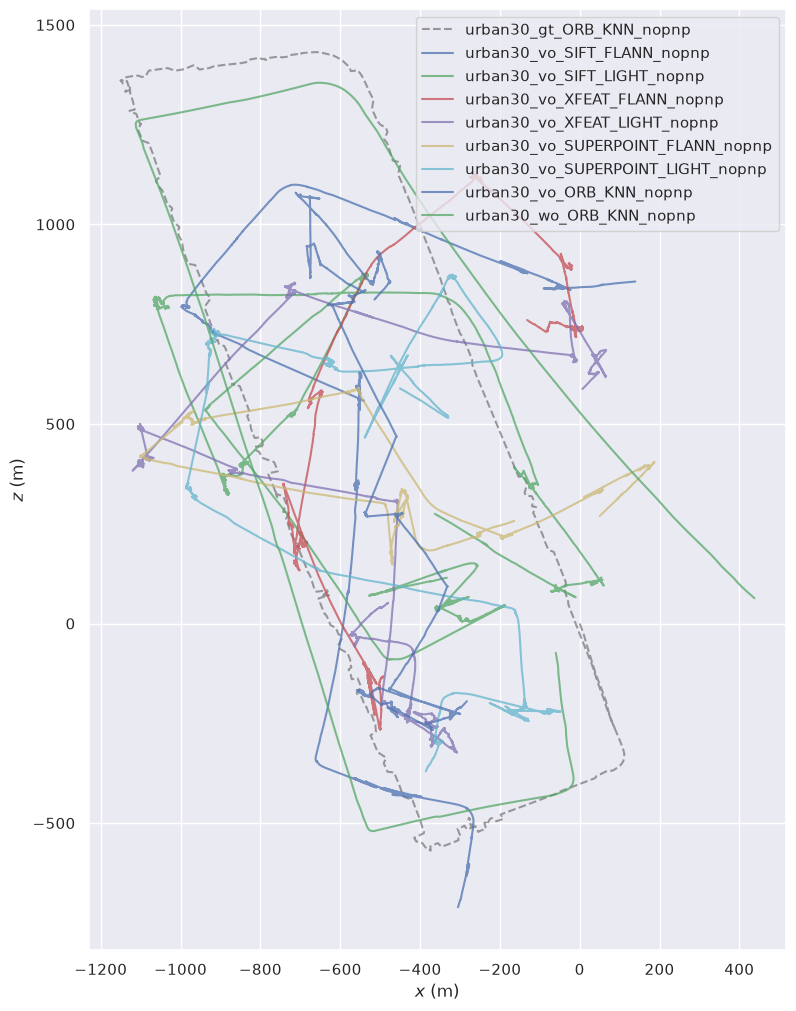


RANKING FINAL DE DESEMPENHO (Baseado no evo_ape e evo_rpe)
Dataset       Configuração  ATE VO (m)  RPE VO (m) ATE WO (m) RPE WO (m) ATE BA (m) RPE BA (m)
urban30       SIFT + FLANN    452.9096      0.8758        N/A        N/A        N/A        N/A
urban30      XFEAT + LIGHT    520.4795      1.0418        N/A        N/A        N/A        N/A
urban30 SUPERPOINT + LIGHT    547.8572      1.0331        N/A        N/A        N/A        N/A
urban30       SIFT + LIGHT    570.9346      1.1818        N/A        N/A        N/A        N/A
urban30          ORB + KNN    575.3689      0.8729   172.0622      1.194        N/A        N/A
urban30      XFEAT + FLANN    585.6647      0.9548        N/A        N/A        N/A        N/A
urban30 SUPERPOINT + FLANN    660.7137      0.8485        N/A        N/A        N/A        N/A

Tabela exportada para: /home/aki/Desktop/GitHub/Python-VO/results/tabela_resultados_finais.csv


In [4]:
# ==========================================
# 3. Pipeline Principal de Avaliação
# ==========================================
print("Iniciando avaliação em lote com o pacote EVO...\n")
resultados = []

for dataset in datasets:
    print(f"{'='*50}\nAnalisando Dataset: {dataset}\n{'='*50}")
    work_dir = os.path.join(BASE_DIR, dataset)
    
    trajetorias_para_plot = {}
    
    # ----------------------------------------------------
    # FLAGS PARA GARANTIR QUE A WO SEJA AVALIADA SÓ UMA VEZ
    # ----------------------------------------------------
    wo_ja_avaliada = False
    kitti_ja_avisado = False
    global_ate_wo = "N/A"
    global_rpe_wo = "N/A"
    
    for desc in descriptors:
        for matcher in matchers:
            for suffix in suffixes:
                suf_str = f"_{suffix}" if suffix else ""
                
                gt_file = os.path.join(work_dir, f"{dataset}_gt_{desc}_{matcher}{suf_str}.txt")
                vo_file = os.path.join(work_dir, f"{dataset}_vo_{desc}_{matcher}{suf_str}.txt")
                wo_file = os.path.join(work_dir, f"{dataset}_wo_{desc}_{matcher}{suf_str}.txt")
                ba_file = os.path.join(work_dir, f"{dataset}_ba_{desc}_{matcher}{suf_str}.txt")
                
                if not os.path.exists(gt_file) or not os.path.exists(vo_file):
                    continue
                
                nome_config = f"{desc} + {matcher}"
                print(f"Avaliando Odometria Visual: {nome_config}")
                
                # --- 1. AVALIAÇÃO DA ODOMETRIA VISUAL (VO) ---
                ate_vo = extract_rmse_from_ape(gt_file, vo_file, apply_scale=True)
                rpe_vo = extract_rmse_from_rpe(gt_file, vo_file, apply_scale=True)
                
                # Só adiciona no dicionário de plotagem se o EVO conseguiu processar a VO (Evita o erro Umeyama)
                if ate_vo is not None:
                    trajetorias_para_plot[f"VO ({nome_config})"] = vo_file
                else:
                    print(f"  [ALERTA] Trajetória inválida/corrompida. Ignorada do plot: {vo_file}")
                
                # --- 2. AVALIAÇÃO DA ODOMETRIA DE RODA (WO) ---
                ate_wo = "N/A"
                rpe_wo = "N/A"
                
                if "kitti" not in dataset.lower():
                    if os.path.exists(wo_file):
                        # Se ainda não foi avaliada, calcula agora
                        if not wo_ja_avaliada:
                            print("Avaliando Odometria de Roda (WO) pela primeira e única vez...")
                            global_ate_wo = extract_rmse_from_ape(gt_file, wo_file, apply_scale=False) 
                            global_rpe_wo = extract_rmse_from_rpe(gt_file, wo_file, apply_scale=False) 
                            
                            # Adiciona ao dicionário de trajetórias (vai aparecer 1 vez só no gráfico)
                            trajetorias_para_plot["Wheel Odometry"] = wo_file
                            wo_ja_avaliada = True
                        
                        # Reusa os valores já calculados para manter a tabela completa
                        ate_wo = global_ate_wo
                        rpe_wo = global_rpe_wo
                else:
                    if not kitti_ja_avisado:
                        print("Dataset KITTI detectado: Pulando avaliação de WO.")
                        kitti_ja_avisado = True
                
                # --- 3. AVALIAÇÃO DO BUNDLE ADJUSTMENT (BA) ---
                ate_ba = "N/A"
                rpe_ba = "N/A"
                if os.path.exists(ba_file):
                    print("Avaliando Bundle Adjustment (BA)...")
                    ate_ba = extract_rmse_from_ape(gt_file, ba_file, apply_scale=True)
                    rpe_ba = extract_rmse_from_rpe(gt_file, ba_file, apply_scale=True)
                    # Só adiciona se for válido
                    if ate_ba is not None:
                        trajetorias_para_plot[f"BA ({nome_config})"] = ba_file

                # --- 4. SALVANDO OS RESULTADOS ---
                resultados.append({
                    "Dataset": dataset,
                    "Configuração": nome_config,
                    "ATE VO (m)": round(ate_vo, 4) if ate_vo else None,
                    "RPE VO (m)": round(rpe_vo, 4) if rpe_vo else None,
                    "ATE WO (m)": round(ate_wo, 4) if isinstance(ate_wo, float) else ate_wo,
                    "RPE WO (m)": round(rpe_wo, 4) if isinstance(rpe_wo, float) else rpe_wo,
                    "ATE BA (m)": round(ate_ba, 4) if isinstance(ate_ba, float) else ate_ba,
                    "RPE BA (m)": round(rpe_ba, 4) if isinstance(rpe_ba, float) else rpe_ba
                })

    # --- 5. GERAÇÃO DO GRÁFICO ---
    if trajetorias_para_plot:
        plot_name = os.path.join(work_dir, f"comparativo_trajetorias_{dataset}")
        plot_combined_trajectories(gt_file, trajetorias_para_plot, plot_name)
        
        imagem_final = plot_name + "_trajectories.png"
        if os.path.exists(imagem_final):
            display(Image(filename=imagem_final))

# ==========================================
# 4. Ranking e Tabela Final
# ==========================================
print("\n" + "="*80)
print("RANKING FINAL DE DESEMPENHO (Baseado no evo_ape e evo_rpe)")
print("="*80)

df_resultados = pd.DataFrame(resultados)
if df_resultados.empty:
    print("[ALERTA] Nenhum arquivo válido foi processado!")
else:
    df_resultados.dropna(subset=['ATE VO (m)'], inplace=True)
    df_resultados = df_resultados.sort_values(by=["Dataset", "ATE VO (m)"])

    print(df_resultados.to_string(index=False))

    caminho_csv = os.path.join(BASE_DIR, "tabela_resultados_finais.csv")
    df_resultados.to_csv(caminho_csv, index=False)
    print(f"\nTabela exportada para: {caminho_csv}")

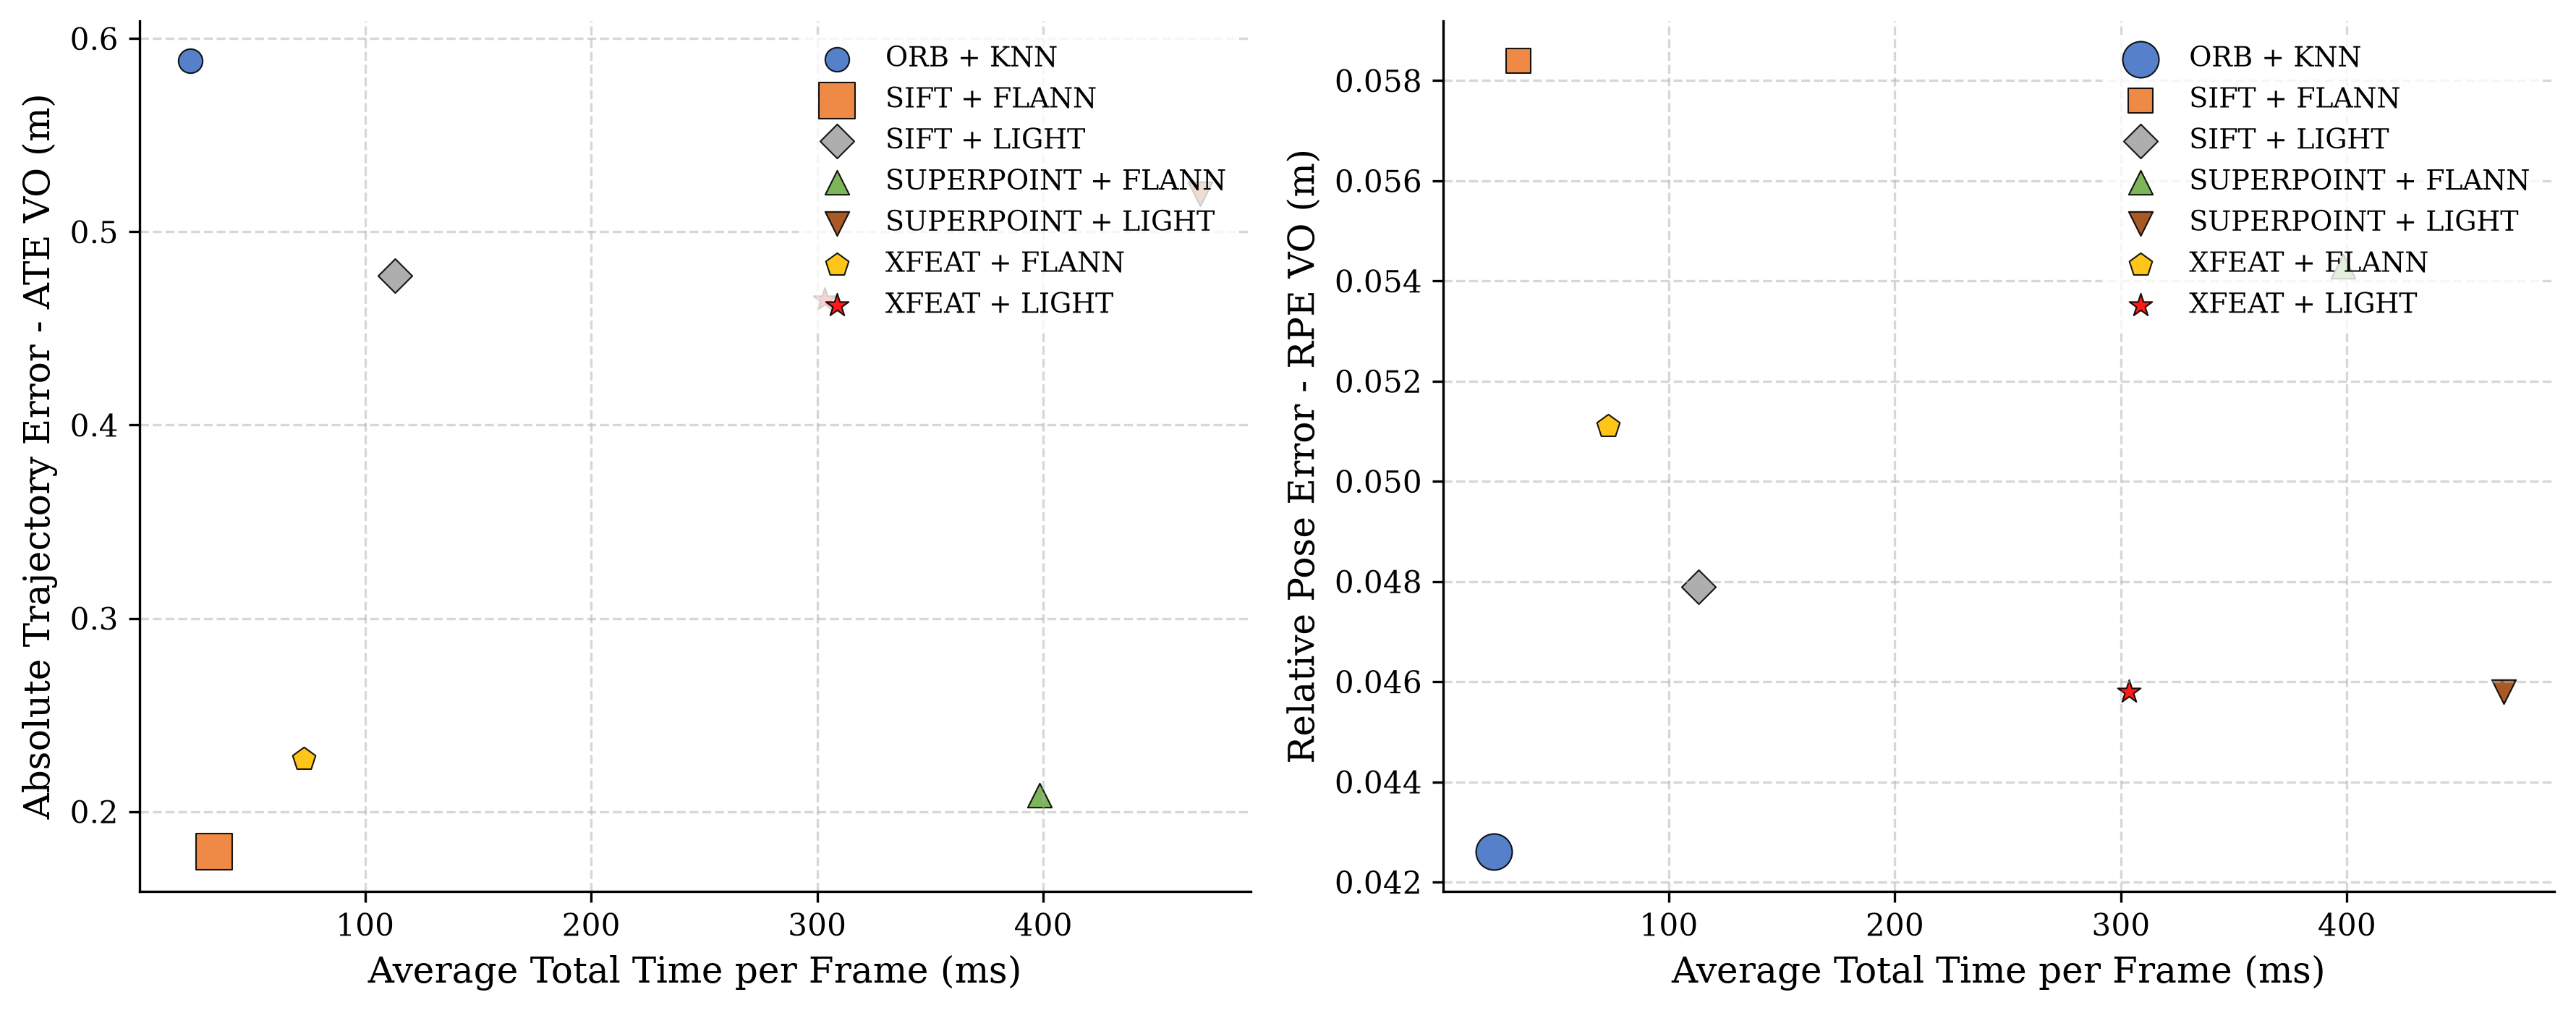

In [1]:
import matplotlib.pyplot as plt

# 1. Configurações de estilo acadêmico (padrão IEEE/SBC)
plt.rcParams.update({
    'font.family': 'serif',       # Fonte clássica com serifa para artigos
    'font.size': 11,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'text.usetex': False          # Mude para True se tiver LaTeX local
})

# 2. Novos dados fornecidos para o cusco_dataset_1
# Formato: 'Config': (Tempo_Total_Segundos * 1000, ATE_VO, RPE_VO, Marcador, Cor)
data_new = {
    'ORB + KNN': (0.02254 * 1000, 0.5886, 0.0426, 'o', '#4472C4'),
    'SIFT + FLANN': (0.03335 * 1000, 0.1791, 0.0584, 's', '#ED7D31'),
    'SIFT + LIGHT': (0.11318 * 1000, 0.4774, 0.0479, 'D', '#A5A5A5'),
    'SUPERPOINT + FLANN': (0.39841 * 1000, 0.2084, 0.0543, '^', '#70AD47'),
    'SUPERPOINT + LIGHT': (0.46937 * 1000, 0.5197, 0.0458, 'v', '#9E480E'),
    'XFEAT + FLANN': (0.07303 * 1000, 0.2272, 0.0511, 'p', '#FFC000'),
    'XFEAT + LIGHT': (0.30344 * 1000, 0.4649, 0.0458, '*', '#FF0000')
}

# Criando a estrutura lado a lado (1 linha, 2 colunas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8), dpi=300)

# ==========================================
# SUBPLOT 1: Absolute Trajectory Error (ATE)
# ==========================================
for label, (time_ms, ate, rpe, marker, color) in data_new.items():
    # Destaca SIFT + FLANN que obteve o menor erro absoluto (ATE) neste dataset
    size = 12 if label == 'SIFT + FLANN' else 8
    ax1.scatter(time_ms, ate, marker=marker, color=color, s=size**2, 
                label=label, alpha=0.9, edgecolors='black', linewidths=0.5)

ax1.set_xlabel('Average Total Time per Frame (ms)')
ax1.set_ylabel('Absolute Trajectory Error - ATE VO (m)')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, linestyle='--', alpha=0.5, which='both')
ax1.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

# ==========================================
# SUBPLOT 2: Relative Pose Error (RPE)
# ==========================================
for label, (time_ms, ate, rpe, marker, color) in data_new.items():
    # Destaca ORB + KNN que obteve o menor erro relativo local (RPE) neste dataset
    size = 12 if label == 'ORB + KNN' else 8
    ax2.scatter(time_ms, rpe, marker=marker, color=color, s=size**2, 
                label=label, alpha=0.9, edgecolors='black', linewidths=0.5)

ax2.set_xlabel('Average Total Time per Frame (ms)')
ax2.set_ylabel('Relative Pose Error - RPE VO (m)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(True, linestyle='--', alpha=0.5, which='both')
ax2.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()

# Salvando em PDF vetorial para o artigo
plt.savefig('cusco_dataset_1_performance_tradeoff.pdf', bbox_inches='tight')
plt.show()

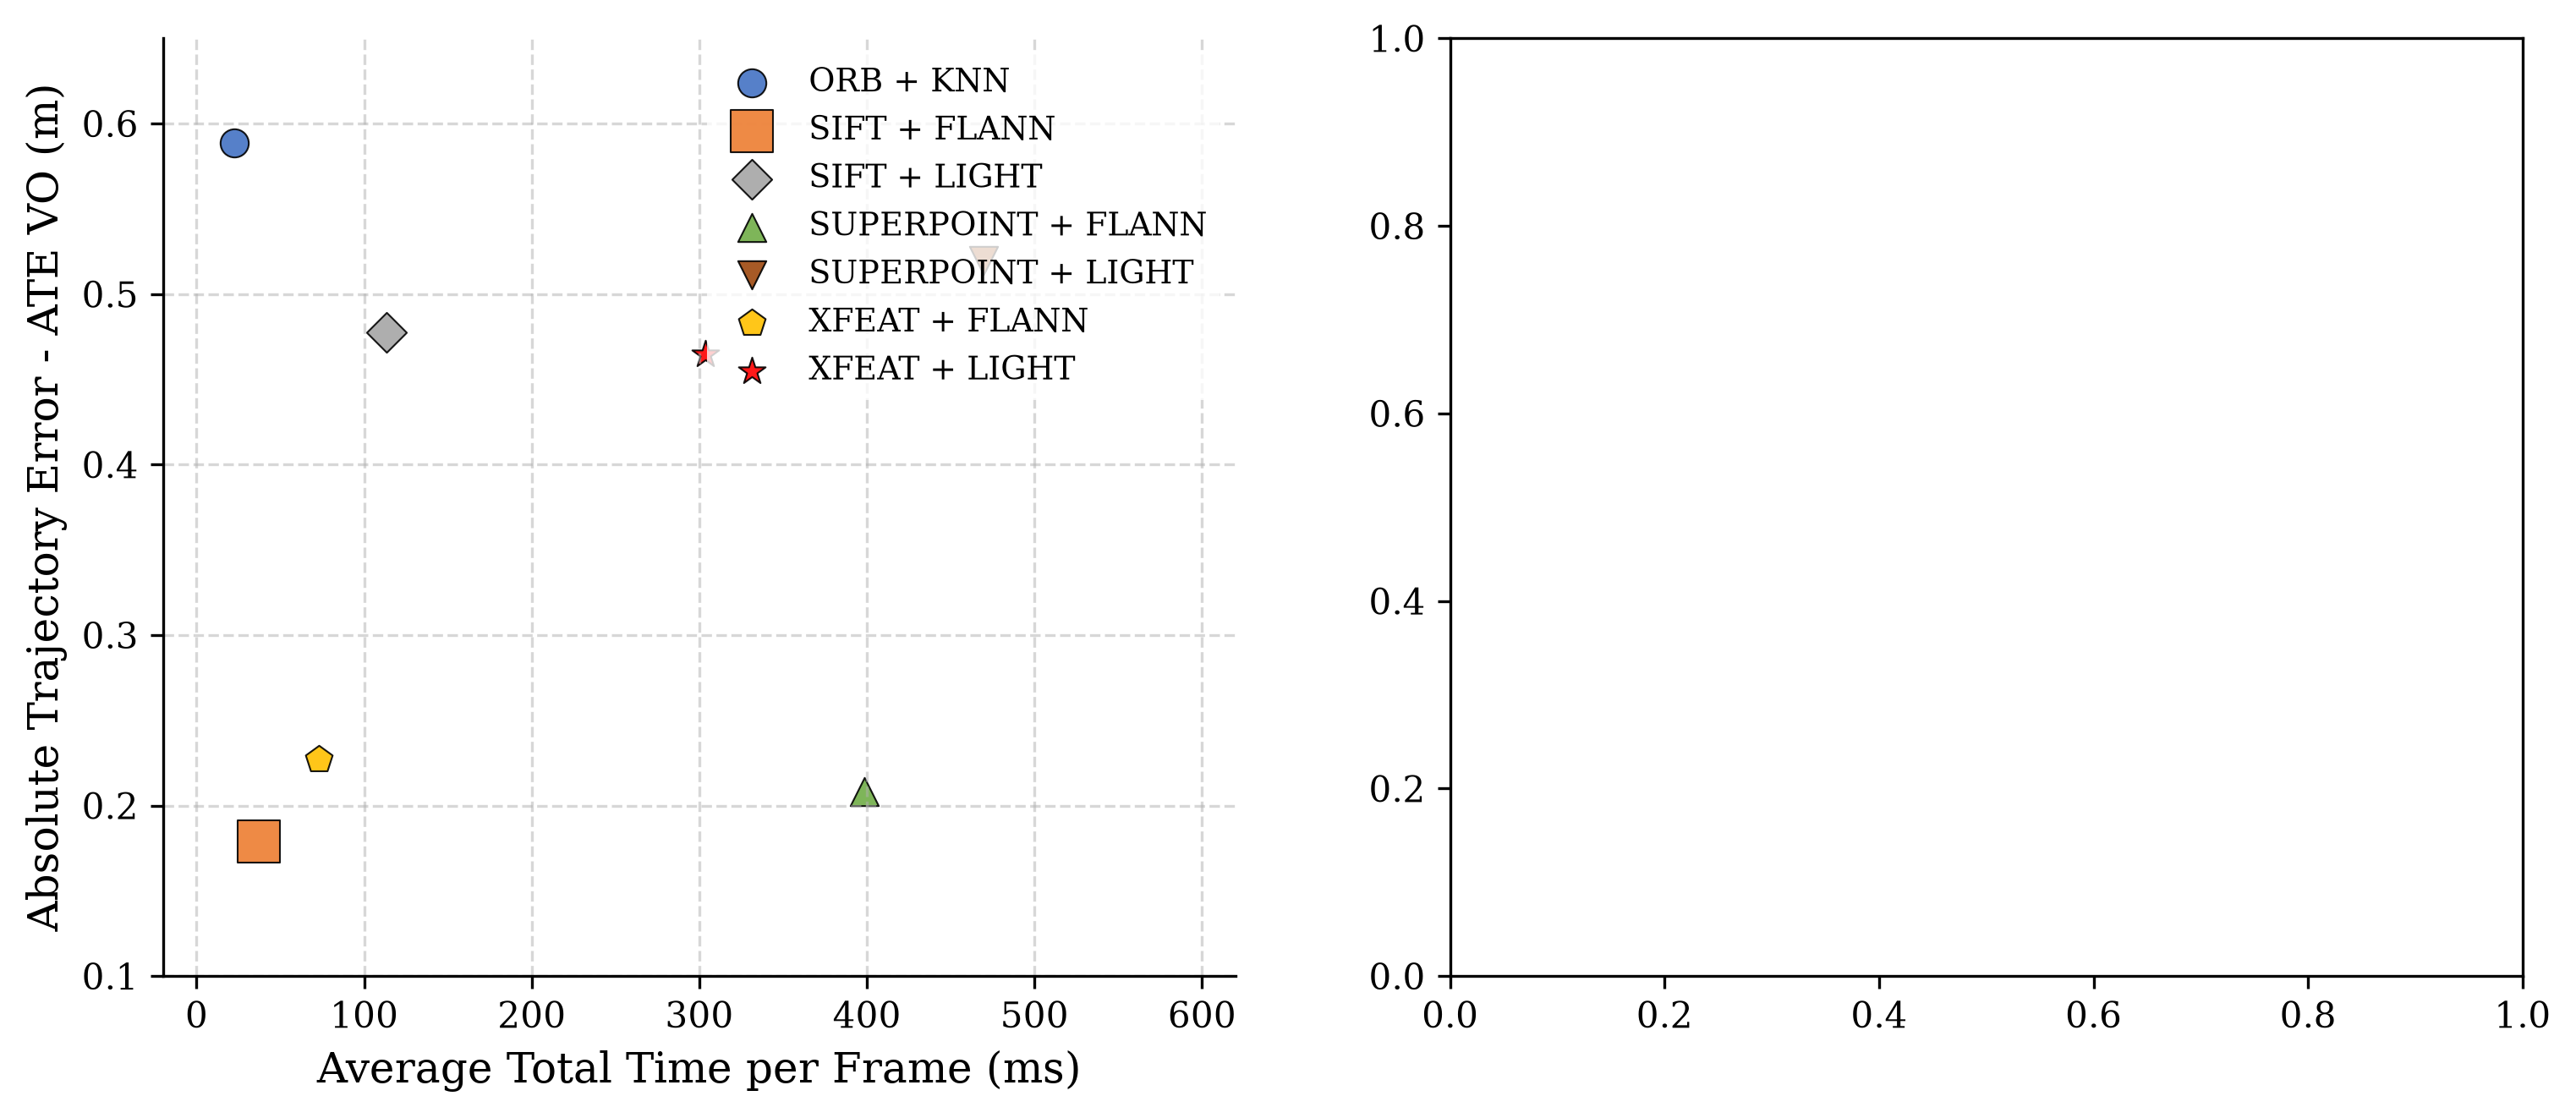

In [ ]:
import matplotlib.pyplot as plt

# 1. Configurações de estilo acadêmico (padrão IEEE/SBC)
plt.rcParams.update({
    'font.family': 'serif',       # Fonte clássica com serifa para artigos
    'font.size': 11,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'text.usetex': False          # Mude para True se tiver LaTeX local
})

# 2. Dados fornecidos para o cusco_dataset_1
data_new = {
    'ORB + KNN': (0.02254 * 1000, 0.5886, 0.0426, 'o', '#4472C4'),
    'SIFT + FLANN': (0.03703 * 1000, 0.1791, 0.0584, 's', '#ED7D31'),
    'SIFT + LIGHT': (0.11318 * 1000, 0.4774, 0.0479, 'D', '#A5A5A5'),
    'SUPERPOINT + FLANN': (0.39841 * 1000, 0.2084, 0.0543, '^', '#70AD47'),
    'SUPERPOINT + LIGHT': (0.46937 * 1000, 0.5197, 0.0458, 'v', '#9E480E'),
    'XFEAT + FLANN': (0.07303 * 1000, 0.2272, 0.0511, 'p', '#FFC000'),
    'XFEAT + LIGHT': (0.30344 * 1000, 0.4649, 0.0458, '*', '#FF0000')
}

# Criando a estrutura lado a lado (1 linha, 2 colunas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8), dpi=300)

# ==========================================
# SUBPLOT 1: Absolute Trajectory Error (ATE)
# ==========================================
for label, (time_ms, ate, rpe, marker, color) in data_new.items():
    size = 12 if label == 'SIFT + FLANN' else 8
    ax1.scatter(time_ms, ate, marker=marker, color=color, s=size**2, 
                label=label, alpha=0.9, edgecolors='black', linewidths=0.5)

ax1.set_xlabel('Average Total Time per Frame (ms)')
ax1.set_ylabel('Absolute Trajectory Error - ATE VO (m)')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, linestyle='--', alpha=0.5, which='both')

# --- EXPANSÃO DOS LIMITES (EVITA SOBREPOSIÇÃO) ---
ax1.set_xlim(-20, 620)
ax1.set_ylim(0.1, 0.65)
ax1.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')




In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib.backends  # Adicione esta linha!

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

data_new = {
    'ORB + KNN': (0.02254 * 1000, 0.5886, 0.0426, 'o', '#4472C4'),
    'SIFT + FLANN': (0.03703 * 1000, 0.1791, 0.0584, 's', '#ED7D31'),
    'SIFT + LightGlue': (0.11318 * 1000, 0.4774, 0.0479, 'D', '#A5A5A5'),
    'Superpoint + FLANN': (0.39841 * 1000, 0.2084, 0.0543, '^', '#70AD47'),
    'Superpoint + LightGlue': (0.46937 * 1000, 0.5197, 0.0458, 'v', '#9E480E'),
    'XFeat + FLANN': (0.07303 * 1000, 0.2272, 0.0511, 'p', '#FFC000'),
    'XFeat + LightGlue': (0.30344 * 1000, 0.4649, 0.0458, '*', '#FF0000')
}

fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=300)

for label, (time_ms, ate, rpe, marker, color) in data_new.items():
    size = 8# if label == 'SIFT + FLANN' else 8
    ax.scatter(time_ms, ate, marker=marker, color=color, s=size**2, 
               label=label, alpha=0.9, edgecolors='black', linewidths=0.5)

ax.set_xlabel('Average Total Time per Frame (ms)')
ax.set_ylabel('Absolute Pose Error - APE VO (m)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.5, which='both')

# Limites para afastar os pontos da legenda
ax.set_xlim(-20, 620)
ax.set_ylim(0.1, 0.8)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.savefig('cusco_dataset_1_ate.pdf', bbox_inches='tight')
plt.show()

AttributeError: module 'matplotlib' has no attribute 'colors'

Error in callback <function _enable_matplotlib_integration.<locals>.configure_once at 0x7fb1675e3b00> (for post_run_cell), with arguments args (<ExecutionResult object at 7fb164c18dd0, execution_count=16 error_before_exec=None error_in_exec=module 'matplotlib' has no attribute 'colors' info=<ExecutionInfo object at 7fb164c18cb0, raw_cell="import matplotlib.pyplot as plt
import matplotlib..." transformed_cell="import matplotlib.pyplot as plt
import matplotlib..." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/home/aki/Desktop/GitHub/Python-VO/Notebooks/output_simulation_verifier.ipynb#X12sZmlsZQ%3D%3D> result=None>,),kwargs {}:


AttributeError: module 'matplotlib' has no attribute 'backends'

In [ ]:
import matplotlib.pyplot as plt

# Reaproveita as mesmas configurações de estilo anteriores
fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=300)

for label, (time_ms, ate, rpe, marker, color) in data_new.items():
    size = 8 #if label == 'ORB + KNN' else 8
    ax.scatter(time_ms, rpe, marker=marker, color=color, s=size**2, 
               label=label, alpha=0.9, edgecolors='black', linewidths=0.5)

ax.set_xlabel('Average Total Time per Frame (ms)')
ax.set_ylabel('Relative Pose Error - RPE VO (m)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.5, which='both')

# Limites calibrados para o RPE
ax.set_xlim(-20, 640)
ax.set_ylim(0.04, 0.066)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.savefig('cusco_dataset_1_rpe.pdf', bbox_inches='tight')
plt.show()

AttributeError: module 'matplotlib' has no attribute 'colors'

Error in callback <function _enable_matplotlib_integration.<locals>.configure_once at 0x7fb1675e3b00> (for post_run_cell), with arguments args (<ExecutionResult object at 7fb1640666c0, execution_count=19 error_before_exec=None error_in_exec=module 'matplotlib' has no attribute 'colors' info=<ExecutionInfo object at 7fb164066810, raw_cell="import matplotlib.pyplot as plt

# Reaproveita as .." transformed_cell="import matplotlib.pyplot as plt

# Reaproveita as .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/home/aki/Desktop/GitHub/Python-VO/Notebooks/output_simulation_verifier.ipynb#X13sZmlsZQ%3D%3D> result=None>,),kwargs {}:


AttributeError: module 'matplotlib' has no attribute 'backends'